In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import torch
from wordcloud import WordCloud

In [14]:
df_01 = pd.read_csv('data/01_full_context_pred.csv')

In [22]:
indo_stopwords = [
    # Basic Indonesian stopwords (keep these)
    "yang", "dan", "di", "dengan", "untuk", "dari", "ke", "pada", "ini", "itu",
    "atau", "ada", "juga", "dalam", "saya", "kamu", "anda", "mereka", "kita", "kami",
    "dia", "nya", "adalah", "akan", "oleh", "seperti", "telah", "sudah", "bisa", "dapat",
    "tidak", "tak", "jangan", "ya", "via", "yg", "dgn", "utk", "dr", "pd", "dlm", "sdh", "tdk",
    "tapi", "aku"
    
    # All candidate names and variations (since they appear everywhere)
    "anies", "baswedan", "rasyid", "muhaimin", "iskandar", "cak", "imin", "gus", 
    "prabowo", "subianto", "gibran", "rakabuming", "raka", "ganjar", "pranowo", 
    "mahfud", "md", "gama", "mawi", "abdurrahman", "abdul", "amin"
    
    # Titles and name prefixes
    "mas", "pak", "bu", "bapak", "ibu", "om", "tante", "mbak", "bro", "sis", "bang", 
    "abang", "kak", "adek", "adik", "kakak", "bung", "prof", "dr", "haji", "hajah", "h",
    
    # Social media expressions
    "rt", "dm", "pm", "cc", "wkwk", "haha", "woi", "hey", "ah", "eh", "oh", "hmm", "btw",
    "omg", "lol", "sih", "aja", "gitu", "banget", "kok", "deh", "ih", "yuk", "mantap",
    "insya", "insyaallah", "alhamdulillah", "bismillah", "amin", "allahuma", "allah",
    
    # Locations
    "jakarta", "jawa", "barat", "timur", "tengah", "utara", "selatan", "sumatra", "bali", 
    "aceh", "kota", "desa", "daerah", "wilayah", "provinsi", "kabupaten", "kawasan",
    "bandung", "surabaya", "makassar", "balikpapan", "semarang", "yogyakarta", "solo", "korea"
    
]

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [ ]:
def run_topic_modeling(df, group_name='ALL'):
     # Set up custom vectorizer
    vectorizer = CountVectorizer(
        stop_words=indo_stopwords,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.7
    )

    # Set up UMAP
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    # Set up HDBSCAN
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    # Set up c-TF-IDF
    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    # Sentence embeddings
    embedding_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

    # BERTopic setup
    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=15,
        min_topic_size=5,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer,
        embedding_model=embedding_model
    )

    # Fit model
    docs = df['full_text'].tolist()
    topics, probs = topic_model.fit_transform(docs)
    
    # Generate custom topic labels
    topic_labels = {}
    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            topic_labels[topic_id] = "outlier"
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:5]]
        if any(term in words for term in ["palestina", "doa", "gelar", "bukittinggi"]):
            topic_labels[topic_id] = "Kampanye Palestina"
        elif any(term in words for term in ["aceh", "warga", "sambut", "bandara", "kedatagan"]):
            topic_labels[topic_id] = "Kunjungan ke Aceh"
        elif any(term in words for term in ["sumbar", "sumatra", "barat", "safari"]):
            topic_labels[topic_id] = "Kampanye Sumatra Barat"
        elif any(term in words for term in ["adil", "makmur", "sejahtera", "rakyat"]):
            topic_labels[topic_id] = "Visi Keadilan & Kemakmuran"
        elif any(term in words for term in ["menang", "indonesia", "senang", "bismillah"]):
            topic_labels[topic_id] = "Dukungan Kemenangan"
        elif any(term in words for term in ["pesantren", "santri", "tenanan", "kiai"]):
            topic_labels[topic_id] = "Dukungan Pesantren & Santri"
        elif any(term in words for term in ["partai", "bangkit", "bangsa"]):
            topic_labels[topic_id] = "Dukungan Partai Politik"
        else:
            topic_labels[topic_id] = " & ".join(words[:3])
    topic_model.set_topic_labels(topic_labels)

    # Topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nTopic Information for: {group_name}")
    print(topic_info.head(10))

    # Print topic summaries
    print(f"\nTopik Pembicaraan Masyarakat terhadap Calon Anies-Cak Imin ({group_name}):")
    for index, row in topic_info.iterrows():
        if row["Topic"] != -1:
            topic_id = row["Topic"]
            words = [word[0] for word in topic_model.get_topic(topic_id)[:8]]
            print(f"Theme: {row['Name']}")
            print(f"Keywords: {', '.join(words)}")
            print(f"Document count: {row['Count']}")
            print("-" * 50)

    # Bar chart of topic distribution
    plt.figure(figsize=(12, 6))
    topic_counts = topic_info[topic_info["Topic"] != -1]["Count"]
    topic_names = [topic_labels[topic] for topic in topic_info[topic_info["Topic"] != -1]["Topic"]]

    bars = plt.bar(topic_names, topic_counts, color=plt.cm.viridis(np.linspace(0, 1, len(topic_counts))))
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribusi Topik: {group_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Topik Pembicaraan", fontsize=12)
    plt.ylabel("Jumlah Tweet", fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Interactive Visualizations
    display(topic_model.visualize_topics())
    display(topic_model.visualize_hierarchy())
    display(topic_model.visualize_heatmap())

    # Word Clouds for top 3 topics
    plt.figure(figsize=(15, 10))
    for i, topic_id in enumerate(topic_info[topic_info['Topic'] != -1]['Topic'][:3]):
        plt.subplot(1, 3, i+1)
        words = dict(topic_model.get_topic(topic_id)[:15])
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap='viridis', max_words=50).generate_from_frequencies(words)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic: {topic_labels[topic_id]}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Representative sentences per topic
    print(f"\nKalimat Representatif untuk Setiap Topik ({group_name}):")
    rep_docs = topic_model.get_representative_docs()
    rows = []
    for topic_id, texts in rep_docs.items():
        if topic_id == -1:
            continue
        rows.append({
            "Topic ID": topic_id,
            "Label": topic_labels[topic_id],
            "Representative Sentence": texts[0]  # You can use texts[:3] for more
        })
    rep_df = pd.DataFrame(rows)
    display(rep_df)

    return topic_model, topics, probs

In [25]:
df_01 = pd.read_csv('data/01_full_context_pred.csv')

2025-05-26 14:52:40,191 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 321/321 [02:43<00:00,  1.96it/s]
2025-05-26 14:55:23,826 - BERTopic - Embedding - Completed ✓
2025-05-26 14:55:23,827 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 14:55:30,286 - BERTopic - Dimensionality - Completed ✓
2025-05-26 14:55:30,288 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 14:55:40,275 - BERTopic - Cluster - Completed ✓
2025-05-26 14:55:40,276 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 14:55:40,927 - BERTopic - Representation - Completed ✓
2025-05-26 14:55:40,928 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 14:55:40,941 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 14:55:41,517 - BERTopic - Representation - Completed ✓
2025-05-26 14:55:41,520 - BERTopic - Topic reduction - Re


Topic Information for: POSITIVE
   Topic  Count                                               Name  \
0     -1   3199            -1_pendukung 01_ayah anies_kasih_terima   
1      0   1664                  0_01 menang_01 01_pilih 01_pintar   
2      1   1587  1_pemilihan presiden_calon presiden_presiden_p...   
3      2   1459          2_ayah anies_pesantren_pemimpin_mas anies   
4      3   1207  3_pasangan calon 01_calon 01_pendukung 01_memilih   
5      4    416    4_republik_makmur_adil makmur_adil makmur semua   
6      5    333    5_debat_dialog_calon wakil presiden_calon wakil   
7      6    123                 6_program_meningkatkan_nakes_kerja   
8      7    105                    7_video_menonton_bagikan_sampai   
9      8     54                  8_palestina_bela_aksi_kemerdekaan   

                                       CustomName  \
0                                         outlier   
1                    01 menang & 01 01 & pilih 01   
2  pemilihan presiden & calon preside

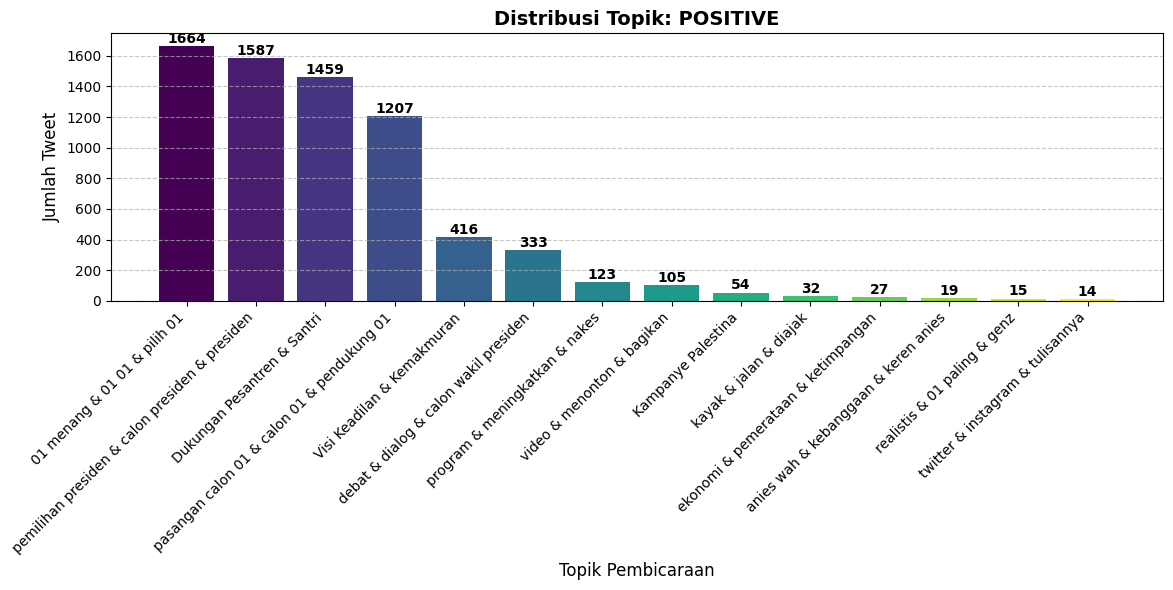

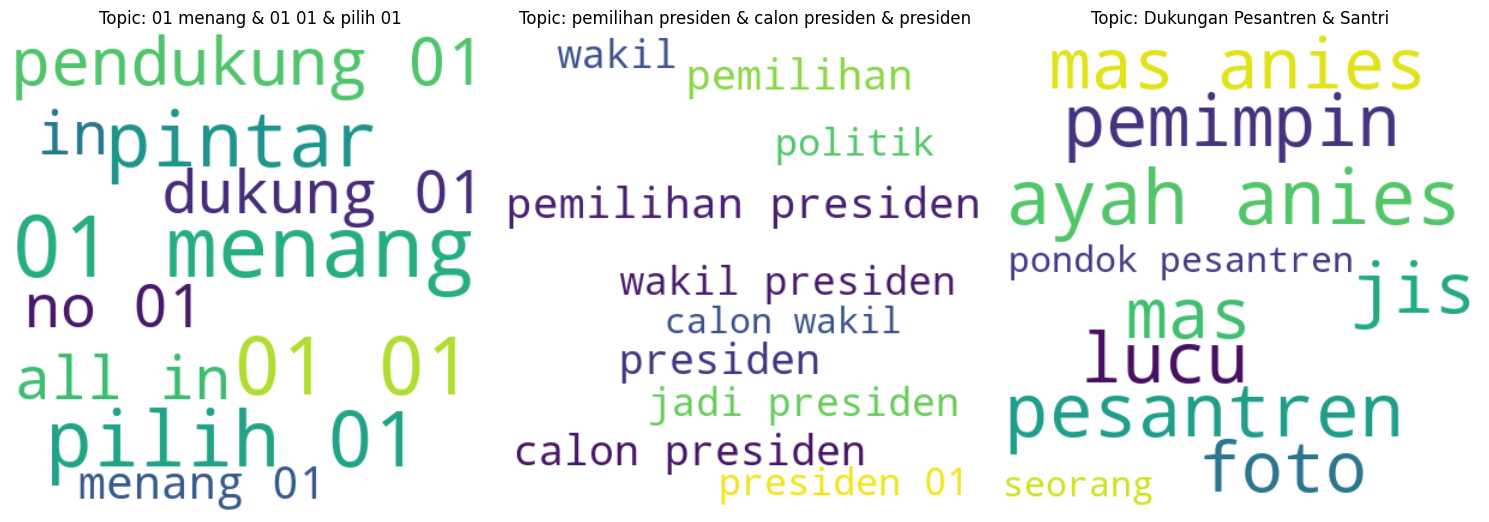


Kalimat Representatif untuk Setiap Topik (POSITIVE):


IndexError: list index out of range

In [26]:
df_positive = df_01[df_01['predicted_label'] == 'POSITIVE']
run_topic_modeling(df_positive, group_name='POSITIVE')

2025-05-26 14:47:38,010 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 424/424 [03:39<00:00,  1.93it/s]
2025-05-26 14:51:17,304 - BERTopic - Embedding - Completed ✓
2025-05-26 14:51:17,305 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 14:51:26,037 - BERTopic - Dimensionality - Completed ✓
2025-05-26 14:51:26,038 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 14:52:01,083 - BERTopic - Cluster - Completed ✓
2025-05-26 14:52:01,084 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 14:52:01,947 - BERTopic - Representation - Completed ✓
2025-05-26 14:52:01,947 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 14:52:01,961 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 14:52:02,686 - BERTopic - Representation - Completed ✓
2025-05-26 14:52:02,689 - BERTopic - Topic reduction - Re


Topic Information for: NEGATIVE
   Topic  Count                                        Name  \
0     -1   4893                  -1_bukan_tahu_pilih_kenapa   
1      0   4376            0_menang_survei_01 menang_pintar   
2      1   2348        1_presiden_demokrasi_pemilihan_video   
3      2    748     2_umum_anies anies_pemilihan umum_warga   
4      3    359                  3_debat_wakil_pas_presiden   
5      4    284                4_identitas_agama_ulama_ikut   
6      5    193         5_twitter_media_media sosial_sosial   
7      6    173         6_salah fokus_tertawa_mirip_blunder   
8      7     57  7_model_model begini_template_begini anies   
9      8     36            8_israel_amerika_lemah_mau kalah   

                         CustomName  \
0                           outlier   
1               Dukungan Kemenangan   
2  presiden & demokrasi & pemilihan   
3                 Kunjungan ke Aceh   
4               debat & wakil & pas   
5         identitas & agama & ulama   


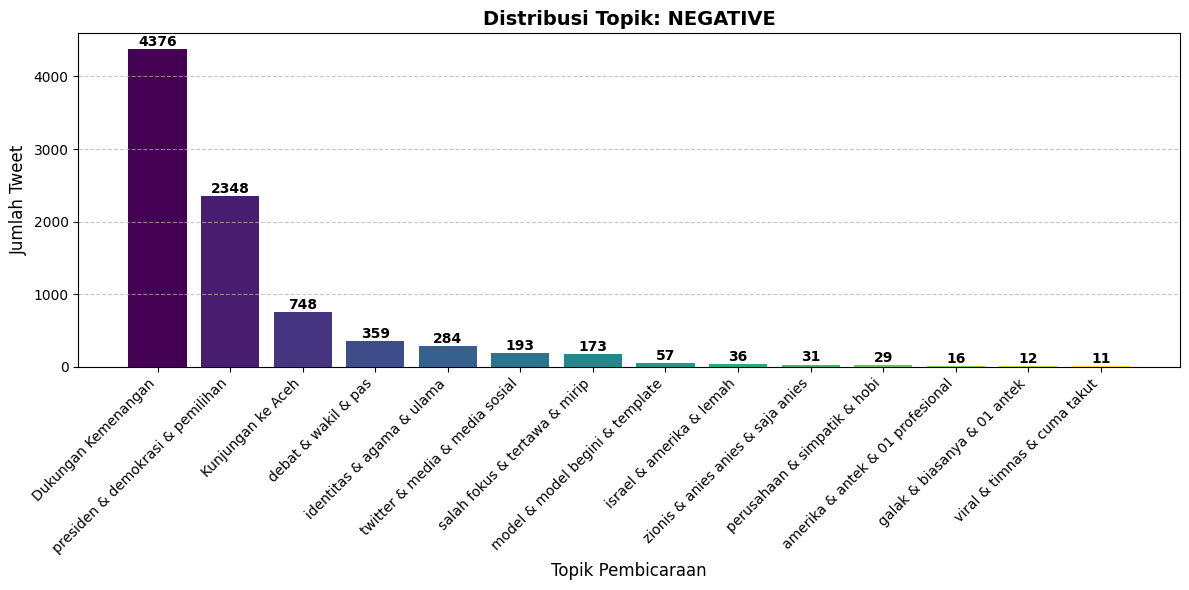

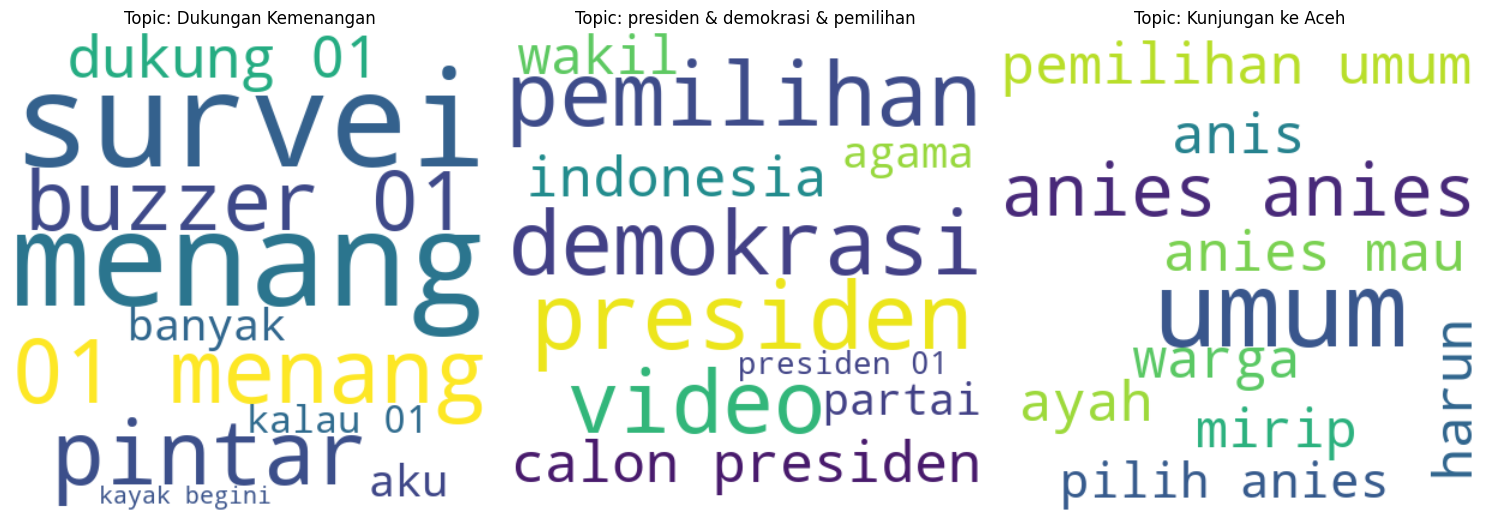

(<bertopic._bertopic.BERTopic at 0x1cb2766d880>,
 [1,
  2,
  2,
  1,
  1,
  1,
  1,
  -1,
  1,
  2,
  1,
  -1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  4,
  1,
  -1,
  1,
  0,
  2,
  -1,
  2,
  1,
  1,
  1,
  -1,
  2,
  -1,
  -1,
  -1,
  2,
  1,
  1,
  -1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  2,
  -1,
  4,
  1,
  2,
  2,
  -1,
  2,
  1,
  1,
  2,
  1,
  2,
  0,
  1,
  4,
  1,
  1,
  1,
  0,
  1,
  2,
  -1,
  2,
  2,
  -1,
  1,
  1,
  -1,
  -1,
  -1,
  1,
  -1,
  2,
  1,
  1,
  1,
  -1,
  2,
  1,
  2,
  1,
  1,
  4,
  1,
  2,
  1,
  1,
  1,
  -1,
  -1,
  2,
  -1,
  2,
  -1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  -1,
  1,
  1,
  1,
  -1,
  2,
  -1,
  2,
  2,
  2,
  2,
  3,
  -1,
  1,
  -1,
  -1,
  1,
  1,
  1,
  -1,
  1,
  1,
  1,
  1,
  1,
  -1,
  -1,
  1,
  -1,
  -1,
  1,
  1,
  -1,
  -1,
  2,
  1,
  2,
  3,
  -1,
  4,
  1,
  2,
  -1,
  2,
  1,
  -1,
  1,
  2,
  1,
  1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  -1,
  1,
  4,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  2,
  

In [ ]:
df_negative = df_01[df_01['predicted_label'] == 'NEGATIVE']
run_topic_modeling(df_negative, group_name='NEGATIVE')

In [ ]:
df_neutral = df_01[df_01['predicted_label'] == 'NEUTRAL']
run_topic_modeling(df_neutral, group_name='NEUTRAL')

2025-05-26 14:52:07,025 - BERTopic - Embedding - Transforming documents to embeddings.
Batches:   7%|▋         | 17/249 [00:21<04:53,  1.27s/it]


KeyboardInterrupt: 